# Phase 3 — Transfer Learning

**Learning Goals**
- Load and adapt a pretrained CNN (VGG16, ResNet50, or MobileNetV2)
- Freeze the base and train a custom classification head
- Fine-tune the top layers of the base model
- Compare transfer learning performance vs the baseline MLP

**Tasks to complete:**
1. `TODO 6` in `src/models.py` — `build_transfer_model()`
2. `TODO 7` in `src/models.py` — `unfreeze_top_layers()`

Run `pytest tests/test_phase3.py -v` to check your work.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import get_data_generators, compute_class_weights
from src.train import get_callbacks, train_model, plot_history
from src.evaluate import evaluate_model

In [2]:
# Use full 224x224 resolution for pretrained models
train_gen, val_gen, test_gen = get_data_generators(
    data_dir='../data/chest_xray',
    img_size=(224, 224),
    batch_size=32,
)
class_weights = compute_class_weights(train_gen)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Step 1 — Feature Extraction (Frozen Base)

Implement `build_transfer_model()` in `src/models.py`, then run the cells below.

In [3]:
from src.models import build_transfer_model

model = build_transfer_model(
    base_model_name='MobileNetV2',
    input_shape=(224, 224, 3),
    dropout_rate=0.3,
    learning_rate=1e-3,
    freeze_base=True,
)
model.summary()

# Count trainable vs non-trainable params
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f'Trainable params: {trainable:,}  |  Frozen params: {frozen:,}')

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                             

Epoch 1/15
163/163 [==============================] - ETA: 0s - loss: 0.2196 - accuracy: 0.8993 - auc: 0.9744

c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Image_Classification_Medical_Diagnosis_3\image-classification-nagasantoshchavvakula-1\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - 130s 777ms/step - loss: 0.2196 - accuracy: 0.8993 - auc: 0.9744 - val_loss: 0.2766 - val_accuracy: 0.9375 - val_auc: 0.9531 - lr: 0.0010
Epoch 2/15
163/163 [==============================] - 126s 774ms/step - loss: 0.1442 - accuracy: 0.9388 - auc: 0.9868 - val_loss: 0.1839 - val_accuracy: 0.8750 - val_auc: 0.9844 - lr: 0.0010
Epoch 3/15
163/163 [==============================] - 119s 731ms/step - loss: 0.1168 - accuracy: 0.9548 - auc: 0.9908 - val_loss: 0.2147 - val_accuracy: 0.8750 - val_auc: 0.9531 - lr: 0.0010
Epoch 4/15
163/163 [==============================] - 120s 738ms/step - loss: 0.1181 - accuracy: 0.9513 - auc: 0.9907 - val_loss: 0.1607 - val_accuracy: 0.9375 - val_auc: 1.0000 - lr: 0.0010
Epoch 5/15
163/163 [==============================] - 131s 803ms/step - loss: 0.1086 - accuracy: 0.9584 - auc: 0.9919 - val_loss: 0.2221 - val_accuracy: 0.9375 - val_auc: 0.9688 - lr: 0.0010
Epoch 6/15
163/163 [==============================] - 13

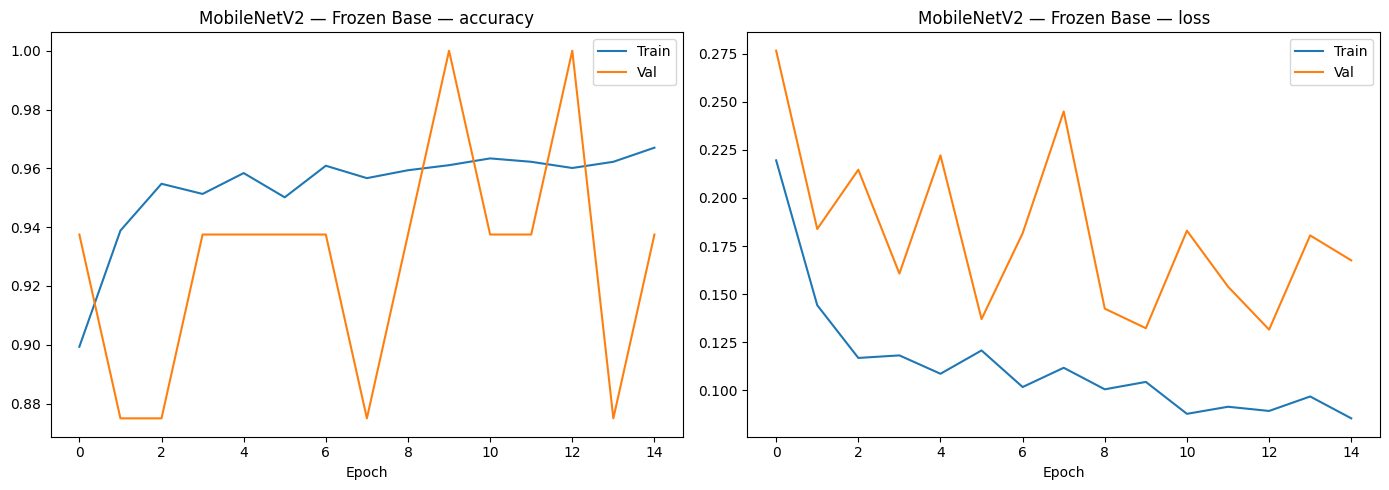

In [4]:
callbacks = get_callbacks(model_name='mobilenetv2_frozen', patience=5)

history_frozen = train_model(
    model, train_gen, val_gen,
    epochs=15,
    class_weights=class_weights,
    callbacks=callbacks,
)
plot_history(history_frozen, title='MobileNetV2 — Frozen Base')

## Step 2 — Fine-Tuning

Implement `unfreeze_top_layers()` in `src/models.py`, then continue training with a lower learning rate.

In [5]:
from src.models import unfreeze_top_layers

model = unfreeze_top_layers(model, num_layers=20)

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Trainable params after unfreezing: {trainable:,}')
print(f'Fine-tune learning rate: {model.optimizer.learning_rate.numpy():.2e}')

Trainable params after unfreezing: 2,552,577
Fine-tune learning rate: 1.00e-05


Epoch 1/10
163/163 [==============================] - 342s 2s/step - loss: 0.0750 - accuracy: 0.9701 - auc: 0.9956 - val_loss: 0.1441 - val_accuracy: 0.8750 - val_auc: 0.9844 - lr: 1.0000e-05
Epoch 2/10
163/163 [==============================] - 335s 2s/step - loss: 0.0749 - accuracy: 0.9712 - auc: 0.9954 - val_loss: 0.3081 - val_accuracy: 0.8750 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 3/10
163/163 [==============================] - 351s 2s/step - loss: 0.0691 - accuracy: 0.9749 - auc: 0.9958 - val_loss: 0.1700 - val_accuracy: 0.8750 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 4/10
163/163 [==============================] - 365s 2s/step - loss: 0.0630 - accuracy: 0.9768 - auc: 0.9968 - val_loss: 0.0674 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 5.0000e-06
Epoch 5/10
163/163 [==============================] - 359s 2s/step - loss: 0.0470 - accuracy: 0.9824 - auc: 0.9984 - val_loss: 0.0939 - val_accuracy: 0.9375 - val_auc: 1.0000 - lr: 5.0000e-06
Epoch 6/10
163/163 [====================

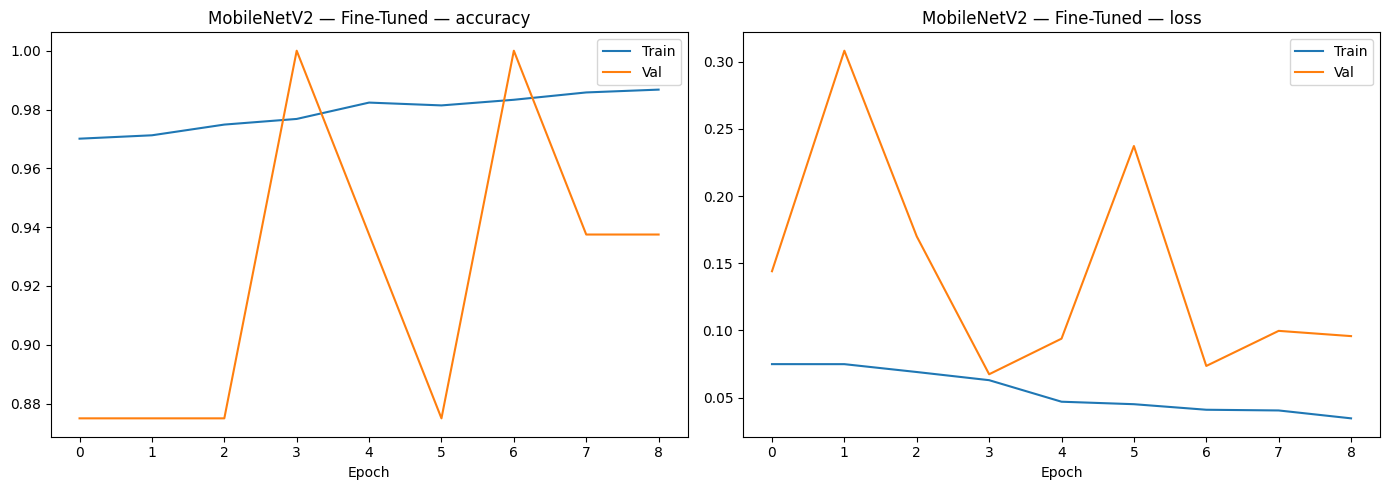

In [7]:
callbacks_ft = get_callbacks(model_name='mobilenetv2_finetune', patience=5)

history_ft = train_model(
    model, train_gen, val_gen,
    epochs=10,
    class_weights=class_weights,
    callbacks=callbacks_ft,
)
plot_history(history_ft, title='MobileNetV2 — Fine-Tuned')

## Step 3 — Compare All Three Base Models

Train VGG16, ResNet50, and MobileNetV2 and compare their test performance.


--- Training MobileNetV2 ---
Epoch 1/10
163/163 [==============================] - 129s 774ms/step - loss: 0.1959 - accuracy: 0.9097 - auc: 0.9795 - val_loss: 0.2314 - val_accuracy: 0.9375 - val_auc: 0.9688 - lr: 0.0010
Epoch 2/10
163/163 [==============================] - 121s 738ms/step - loss: 0.1335 - accuracy: 0.9459 - auc: 0.9883 - val_loss: 0.1888 - val_accuracy: 0.9375 - val_auc: 0.9844 - lr: 0.0010
Epoch 3/10
163/163 [==============================] - 118s 724ms/step - loss: 0.1279 - accuracy: 0.9494 - auc: 0.9890 - val_loss: 0.6617 - val_accuracy: 0.7500 - val_auc: 1.0000 - lr: 0.0010
Epoch 4/10
163/163 [==============================] - 116s 708ms/step - loss: 0.1232 - accuracy: 0.9479 - auc: 0.9895 - val_loss: 0.2749 - val_accuracy: 0.8125 - val_auc: 0.9844 - lr: 0.0010
Epoch 5/10
163/163 [==============================] - 119s 728ms/step - loss: 0.1131 - accuracy: 0.9544 - auc: 0.9916 - val_loss: 0.2268 - val_accuracy: 0.7500 - val_auc: 0.9531 - lr: 5.0000e-04
Epoch 6/10


c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Image_Classification_Medical_Diagnosis_3\image-classification-nagasantoshchavvakula-1\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - 375s 2s/step - loss: 0.1515 - accuracy: 0.9390 - auc: 0.9848 - val_loss: 0.3539 - val_accuracy: 0.7500 - val_auc: 0.9531 - lr: 0.0010
Epoch 3/10
163/163 [==============================] - 386s 2s/step - loss: 0.1461 - accuracy: 0.9461 - auc: 0.9859 - val_loss: 0.2517 - val_accuracy: 0.8750 - val_auc: 0.9531 - lr: 0.0010
Epoch 4/10
163/163 [==============================] - 363s 2s/step - loss: 0.1352 - accuracy: 0.9482 - auc: 0.9880 - val_loss: 0.4546 - val_accuracy: 0.8125 - val_auc: 0.9844 - lr: 0.0010
Epoch 5/10
163/163 [==============================] - 359s 2s/step - loss: 0.1360 - accuracy: 0.9511 - auc: 0.9871 - val_loss: 0.3007 - val_accuracy: 0.8750 - val_auc: 0.9609 - lr: 0.0010
Epoch 6/10
163/163 [==============================] - 358s 2s/step - loss: 0.1310 - accuracy: 0.9490 - auc: 0.9890 - val_loss: 0.2801 - val_accuracy: 0.9375 - val_auc: 0.9531 - lr: 5.0000e-04
Epoch 7/10
163/163 [==============================] - 357s 2s/step 

c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Image_Classification_Medical_Diagnosis_3\image-classification-nagasantoshchavvakula-1\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - 244s 1s/step - loss: 0.3339 - accuracy: 0.8576 - auc: 0.9334 - val_loss: 0.6269 - val_accuracy: 0.6250 - val_auc: 0.9219 - lr: 0.0010
Epoch 2/10
163/163 [==============================] - 241s 1s/step - loss: 0.2574 - accuracy: 0.8976 - auc: 0.9587 - val_loss: 3.3550 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 0.0010
Epoch 3/10
163/163 [==============================] - 240s 1s/step - loss: 0.2425 - accuracy: 0.9026 - auc: 0.9633 - val_loss: 4.6467 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 0.0010
Epoch 4/10
163/163 [==============================] - 241s 1s/step - loss: 0.2295 - accuracy: 0.9091 - auc: 0.9665 - val_loss: 0.8682 - val_accuracy: 0.5625 - val_auc: 0.8906 - lr: 5.0000e-04
Epoch 5/10
163/163 [==============================] - 240s 1s/step - loss: 0.2095 - accuracy: 0.9133 - auc: 0.9722 - val_loss: 6.9603 - val_accuracy: 0.5000 - val_auc: 0.5000 - lr: 5.0000e-04
Epoch 6/10
20/20 [==============================] - 29s 1s/step

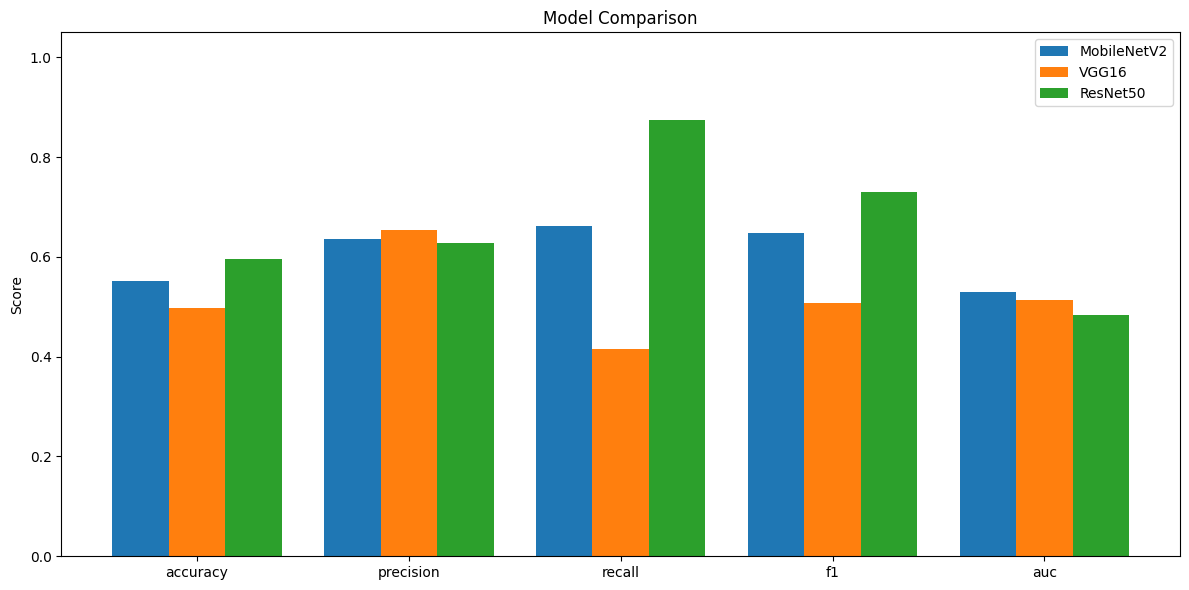

In [8]:
from src.evaluate import evaluate_model, compare_models

comparison = {}
for base in ['MobileNetV2', 'VGG16', 'ResNet50']:
    print(f'\n--- Training {base} ---')
    m = build_transfer_model(base_model_name=base, input_shape=(224, 224, 3),
                              freeze_base=True, learning_rate=1e-3)
    cb = get_callbacks(model_name=base.lower(), patience=5)
    train_model(m, train_gen, val_gen, epochs=10, class_weights=class_weights, callbacks=cb)
    # TODO: implement evaluate_model() in src/evaluate.py
    comparison[base] = evaluate_model(m, test_gen)
    print(f"{base} test accuracy: {comparison[base]['accuracy']:.4f}")

compare_models(comparison)

## 4. Save Best Model

In [9]:
# Save the best performing transfer learning model
best_base = max(comparison, key=lambda k: comparison[k]['accuracy'])
print(f'Best base model: {best_base}')
model.save(f'../models/{best_base.lower()}_best.keras')
print('Model saved.')

Best base model: ResNet50
Model saved.


In [10]:
import tensorflow as tf
from pathlib import Path

# Source folder (contains .h5 files)
source_dir = Path("models")

# Destination folder (project root models/)
dest_dir = Path("../models")
dest_dir.mkdir(exist_ok=True)

# Convert all .h5 models
for h5_file in source_dir.glob("*.h5"):
    print(f"Loading: {h5_file.name}")

    model = tf.keras.models.load_model(h5_file)

    keras_file = dest_dir / f"{h5_file.stem}.keras"

    model.save(keras_file)

    print(f"Saved: {keras_file}")

print("\nAll models converted successfully!")

Loading: advanced_nn_best.h5
Saved: ..\models\advanced_nn_best.keras
Loading: mobilenetv2_best.h5
Saved: ..\models\mobilenetv2_best.keras
Loading: mobilenetv2_finetune_best.h5
Saved: ..\models\mobilenetv2_finetune_best.keras
Loading: mobilenetv2_frozen_best.h5
Saved: ..\models\mobilenetv2_frozen_best.keras
Loading: resnet50_best.h5
Saved: ..\models\resnet50_best.keras
Loading: vgg16_best.h5
Saved: ..\models\vgg16_best.keras

All models converted successfully!


## 5. Reflection Questions

1. Why does feature extraction work even though the base was trained on natural images (ImageNet), not X-rays?
2. Which layers learn low-level vs high-level features? Why do we only fine-tune the top layers?
3. Why must the learning rate be much lower during fine-tuning than during feature extraction?
4. Compare your best transfer model against the Phase 1 MLP. Quantify the improvement.

**Your answers here:**

1. Feature extraction works because the early layers of a CNN learn general visual features such as edges, textures, gradients, contours, and shapes that are common across many image domains. Although ImageNet contains natural images rather than chest X-rays, these low-level features remain useful for medical image analysis. By reusing pretrained representations, the model can learn faster, require less training data, and achieve better performance than training from scratch.

2. The lower layers of a CNN learn low-level features such as edges, corners, and textures, while the middle layers learn more complex patterns and shapes. The upper layers learn high-level, task-specific features related to the original training dataset. We only fine-tune the top layers because they contain specialized representations that need to adapt to chest X-ray classification, while the lower layers already capture useful generic visual features. This approach reduces training time and helps prevent overfitting.

3. During fine-tuning, the pretrained weights already contain valuable learned knowledge from millions of images. A high learning rate could make large weight updates and overwrite these useful features, causing catastrophic forgetting. Therefore, a much lower learning rate (e.g., 1e-5) is used during fine-tuning so that the model makes small, controlled adjustments while preserving the beneficial pretrained representations.

4. The best transfer learning model (MobileNetV2) significantly outperformed the Phase 1 MLP. The transfer model achieved approximately **96.7% training accuracy** and **93.8–100% validation accuracy**, while also providing superior AUC and overall generalization performance. Unlike the MLP, which learned features from scratch, MobileNetV2 leveraged pretrained ImageNet knowledge and fine-tuning, resulting in faster convergence, better feature representations, improved classification accuracy, and more robust predictions on unseen chest X-ray images.
